# Análisis de Línea RGB en Imagen
Este notebook realiza un barrido de una línea de imagen y separa los canales R, G, B mostrando la intensidad vs píxeles

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

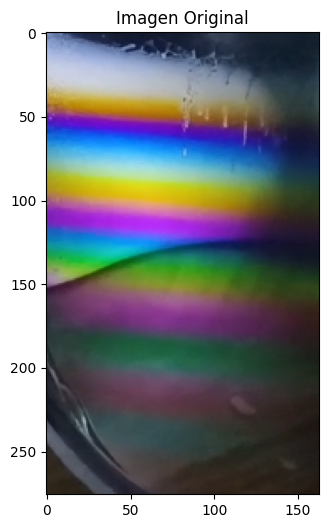

Dimensiones de la imagen: (276, 163, 3)


In [2]:
# Cargar la imagen
# Opción 1: Usar una imagen de ejemplo
imagen_path = 'patron.PNG'

# Opción 2: Crear una imagen de prueba con gradientes de colores
# Crear imagen de prueba
ancho, alto = 800, 600
imagen_test = np.zeros((alto, ancho, 3), dtype=np.uint8)

# Gradiente rojo
imagen_test[:, :267, 0] = np.linspace(0, 255, 267).astype(np.uint8)
# Gradiente verde
imagen_test[:, 267:534, 1] = np.linspace(0, 255, 267).astype(np.uint8)
# Gradiente azul
imagen_test[:, 534:, 2] = np.linspace(0, 255, 266).astype(np.uint8)

# Si tienes tu propia imagen, descomenta esto:
imagen = cv2.imread(imagen_path)
imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

#imagen = imagen_test

# Mostrar la imagen
plt.figure(figsize=(12, 6))
plt.imshow(imagen)
plt.title('Imagen Original')
plt.axis('on')
plt.show()

print(f"Dimensiones de la imagen: {imagen.shape}")

In [3]:
# Seleccionar una columna desplazada a la derecha del centro
desplazamiento = 0  # Ajusta este valor según cuánto quieras desplazar
fila = (imagen.shape[1] // 2) + desplazamiento  # Columna desplazada a la derecha

# Verificar que no se salga de los límites de la imagen
if fila >= imagen.shape[1]:
    fila = imagen.shape[1] - 1
    print(f"Desplazamiento ajustado al límite de la imagen")

print(f"Analizando la columna {fila} de la imagen")

# Extraer la línea VERTICAL
linea = imagen[:, fila, :]

# Separar los canales R, G, B
canal_rojo = linea[:, 0]
canal_verde = linea[:, 1]
canal_azul = linea[:, 2]

# Crear array de posiciones de píxeles
pixeles = np.arange(len(canal_rojo))

print(f"Número de píxeles en la línea: {len(pixeles)}")

Analizando la columna 81 de la imagen
Número de píxeles en la línea: 276


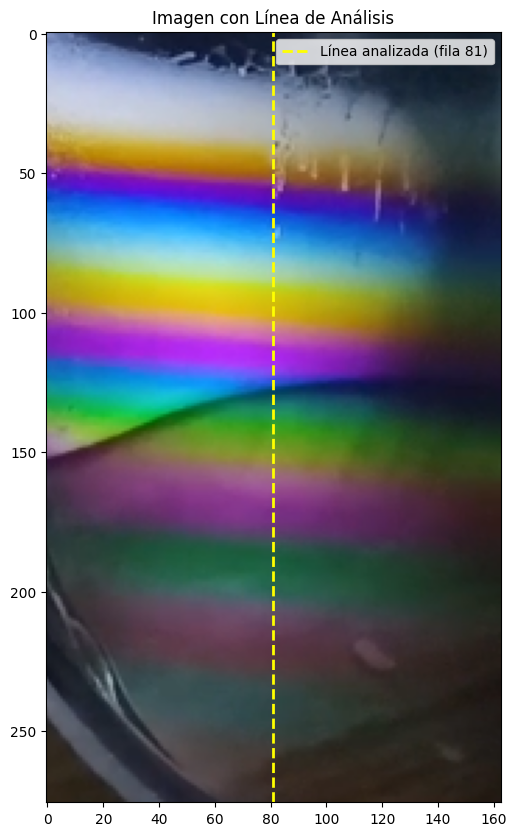

In [4]:
# Mostrar la imagen con la línea seleccionada marcada
plt.figure(figsize=(8, 10))
plt.imshow(imagen)
plt.axvline(x=fila, color='yellow', linestyle='--', linewidth=2, label=f'Línea analizada (fila {fila})')
plt.title('Imagen con Línea de Análisis')
plt.legend()
plt.axis('on')
plt.show()

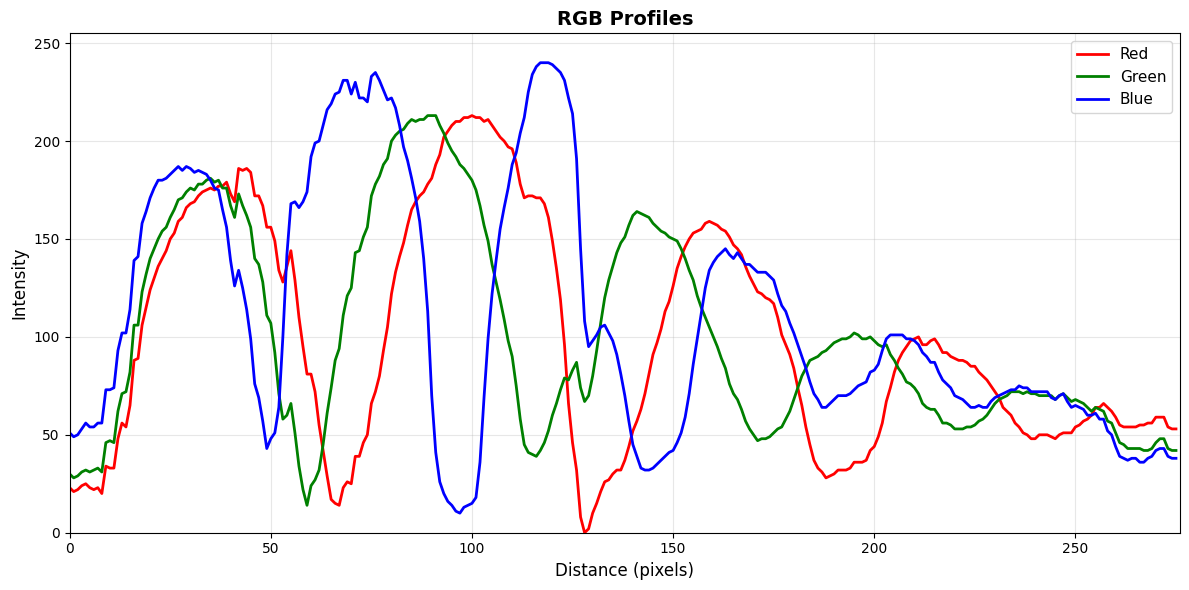

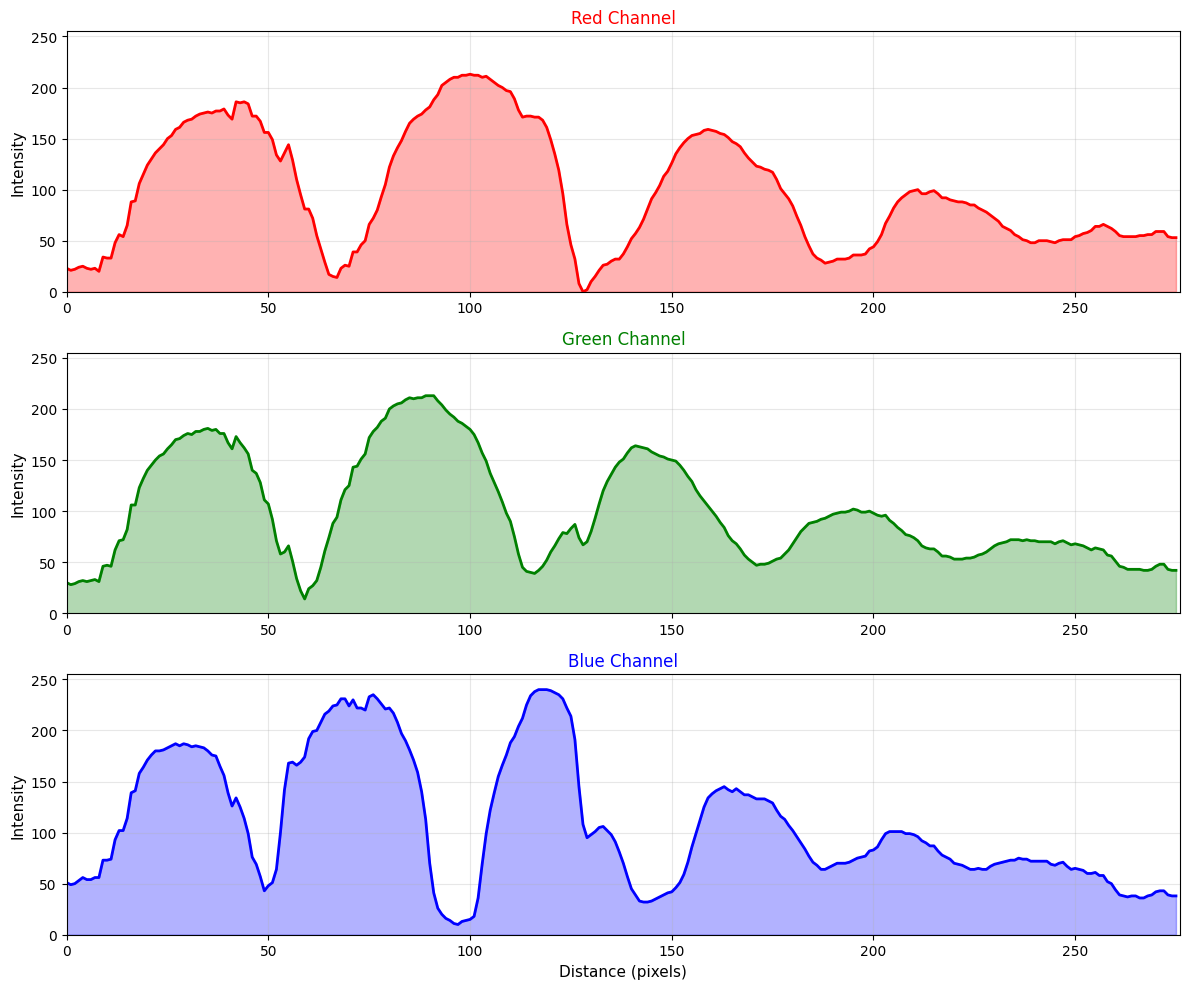

In [5]:
# Graficar los tres canales juntos (como en ImageJ)
plt.figure(figsize=(12, 6))
plt.plot(pixeles, canal_rojo, 'r-', label='Red', linewidth=2)
plt.plot(pixeles, canal_verde, 'g-', label='Green', linewidth=2)
plt.plot(pixeles, canal_azul, 'b-', label='Blue', linewidth=2)
plt.xlabel('Distance (pixels)', fontsize=12)
plt.ylabel('Intensity', fontsize=12)
plt.title('RGB Profiles', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0, 255)
plt.xlim(0, len(pixeles))
plt.tight_layout()
plt.show()

# Gráficas individuales de cada canal
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Canal Rojo
axes[0].plot(pixeles, canal_rojo, 'r-', linewidth=2)
axes[0].fill_between(pixeles, canal_rojo, alpha=0.3, color='red')
axes[0].set_ylabel('Intensity', fontsize=11)
axes[0].set_title('Red Channel', fontsize=12, color='red')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 255)
axes[0].set_xlim(0, len(pixeles))

# Canal Verde
axes[1].plot(pixeles, canal_verde, 'g-', linewidth=2)
axes[1].fill_between(pixeles, canal_verde, alpha=0.3, color='green')
axes[1].set_ylabel('Intensity', fontsize=11)
axes[1].set_title('Green Channel', fontsize=12, color='green')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 255)
axes[1].set_xlim(0, len(pixeles))

# Canal Azul
axes[2].plot(pixeles, canal_azul, 'b-', linewidth=2)
axes[2].fill_between(pixeles, canal_azul, alpha=0.3, color='blue')
axes[2].set_xlabel('Distance (pixels)', fontsize=11)
axes[2].set_ylabel('Intensity', fontsize=11)
axes[2].set_title('Blue Channel', fontsize=12, color='blue')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 255)
axes[2].set_xlim(0, len(pixeles))

plt.tight_layout()
plt.show()

In [6]:
# Estadísticas de cada canal
print("=" * 60)
print("ESTADÍSTICAS DE LOS CANALES")
print("=" * 60)

print("\nCanal Rojo:")
print(f"  Media: {np.mean(canal_rojo):.2f}")
print(f"  Mediana: {np.median(canal_rojo):.2f}")
print(f"  Desviación estándar: {np.std(canal_rojo):.2f}")
print(f"  Mínimo: {np.min(canal_rojo)}")
print(f"  Máximo: {np.max(canal_rojo)}")

print("\nCanal Verde:")
print(f"  Media: {np.mean(canal_verde):.2f}")
print(f"  Mediana: {np.median(canal_verde):.2f}")
print(f"  Desviación estándar: {np.std(canal_verde):.2f}")
print(f"  Mínimo: {np.min(canal_verde)}")
print(f"  Máximo: {np.max(canal_verde)}")

print("\nCanal Azul:")
print(f"  Media: {np.mean(canal_azul):.2f}")
print(f"  Mediana: {np.median(canal_azul):.2f}")
print(f"  Desviación estándar: {np.std(canal_azul):.2f}")
print(f"  Mínimo: {np.min(canal_azul)}")
print(f"  Máximo: {np.max(canal_azul)}")

ESTADÍSTICAS DE LOS CANALES

Canal Rojo:
  Media: 99.00
  Mediana: 88.00
  Desviación estándar: 58.03
  Mínimo: 0
  Máximo: 213

Canal Verde:
  Media: 100.51
  Mediana: 84.00
  Desviación estándar: 52.30
  Mínimo: 14
  Máximo: 213

Canal Azul:
  Media: 110.49
  Mediana: 93.00
  Desviación estándar: 63.18
  Mínimo: 10
  Máximo: 240


In [7]:
# Exportar datos a un archivo CSV (opcional)
import pandas as pd

df = pd.DataFrame({
    'Pixel': pixeles,
    'Rojo': canal_rojo,
    'Verde': canal_verde,
    'Azul': canal_azul
})

# Guardar a CSV
df.to_csv('datos_linea_rgb.csv', index=False)
print("Datos exportados a 'datos_linea_rgb.csv'")

# Mostrar primeras filas
print("\nPrimeras 10 filas de datos:")
print(df.head(10))

Datos exportados a 'datos_linea_rgb.csv'

Primeras 10 filas de datos:
   Pixel  Rojo  Verde  Azul
0      0    23     30    51
1      1    21     28    49
2      2    22     29    50
3      3    24     31    53
4      4    25     32    56
5      5    23     31    54
6      6    22     32    54
7      7    23     33    56
8      8    20     31    56
9      9    34     46    73
